In [1]:
!pip install shap tensorflow

In [2]:
import json
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import shap
import numpy as np
import matplotlib.pyplot as plt

In [5]:
model = ResNet50(weights="imagenet")
X, y = shap.datasets.imagenet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
X = np.clip(X, 0, 255).astype(np.uint8)

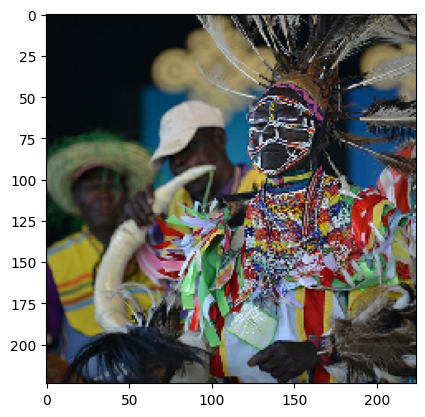

In [16]:
plt.imshow(X[7])

In [18]:
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with open(shap.datasets.cache(url)) as file:
  class_names = [v[1] for v in json.load(file).values()]

In [19]:
print(f"Number of ImageNet Classes: {len(class_names)}")
print(f"Class Names: {class_names}")

Number of ImageNet Classes: 1000
Class Names: ['tench', 'goldfish', 'great_white_shark', 'tiger_shark', 'hammerhead', 'electric_ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house_finch', 'junco', 'indigo_bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water_ouzel', 'kite', 'bald_eagle', 'vulture', 'great_grey_owl', 'European_fire_salamander', 'common_newt', 'eft', 'spotted_salamander', 'axolotl', 'bullfrog', 'tree_frog', 'tailed_frog', 'loggerhead', 'leatherback_turtle', 'mud_turtle', 'terrapin', 'box_turtle', 'banded_gecko', 'common_iguana', 'American_chameleon', 'whiptail', 'agama', 'frilled_lizard', 'alligator_lizard', 'Gila_monster', 'green_lizard', 'African_chameleon', 'Komodo_dragon', 'African_crocodile', 'American_alligator', 'triceratops', 'thunder_snake', 'ringneck_snake', 'hognose_snake', 'green_snake', 'king_snake', 'garter_snake', 'water_snake', 'vine_snake', 'night_snake', 'boa_constrictor', 'rock_python', 'Indian_cobra', 'green_mamba'

In [27]:
def f(x):
  tmp = x.copy()
  preprocess_input(tmp)
  return model(tmp)

# Define masker that is used to mask out partitions of the input image
masker = shap.maskers.Image("inpaint_telea", X[0].shape)

# Create explainer with model and image masker
explainer = shap.Explainer(f, masker, output_names=class_names)

shap_values = explainer(
    X[1:3], max_evals=100, batch_size=50, outputs=shap.Explanation.argsort.flip[:4]
)

  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [00:54, 27.21s/it]


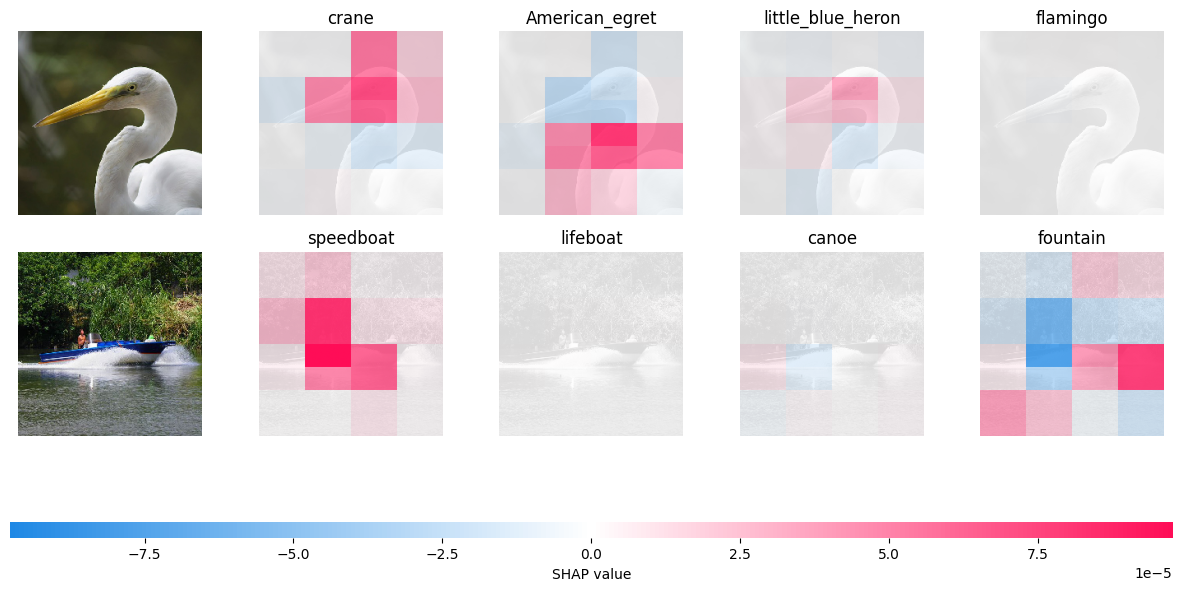

In [28]:
shap.image_plot(shap_values)

In [29]:
def f(x):
  tmp = x.copy()
  preprocess_input(tmp)
  return model(tmp)

masked_blur = shap.maskers.Image("blur(128,128)", X[0].shape)

explainer_blur = shap.Explainer(f, masked_blur, output_names=class_names)

shap_values_fine = explainer_blur(
    X[1:3], max_evals=500, batch_size=50, outputs=shap.Explanation.argsort.flip[:4]
)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [03:29, 104.73s/it]


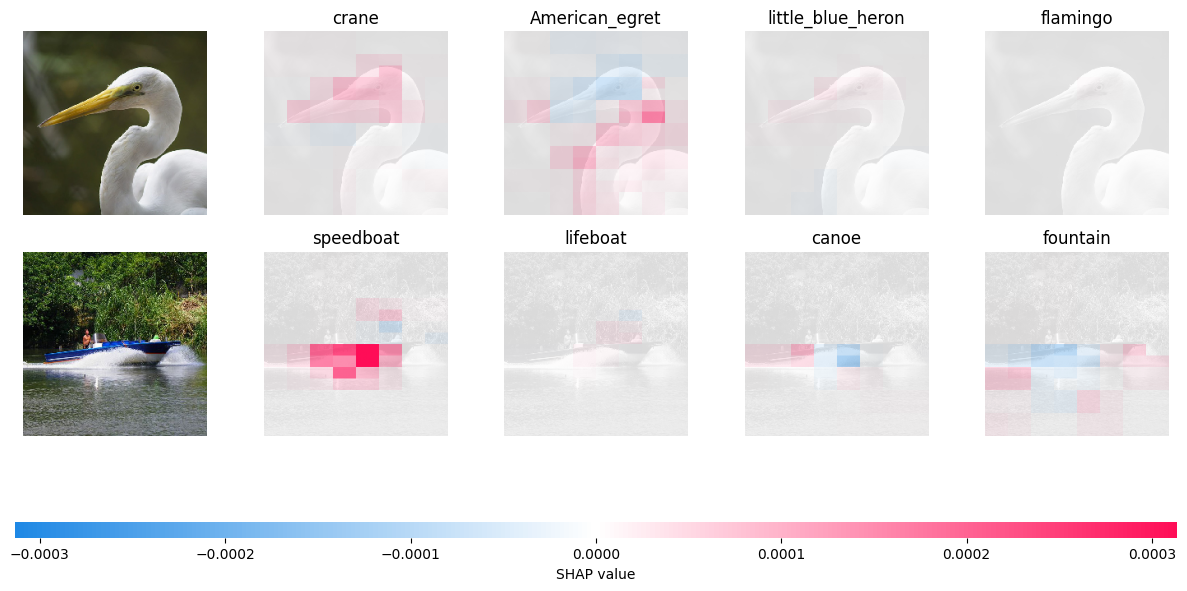

In [30]:
shap.image_plot(shap_values_fine)